# EDA TP Grupo N°13 — Yellow Taxi NYC (26Co2026)

**Plan A — Problema de ML: predecir la _propina_ como proporción de la tarifa (`tip_pct = tip_amount / fare_amount`).**
Plan B (respaldo, predecir `duration_min`) en `tp_grupal_eda_planB_duracion.ipynb`.

Análisis exploratorio.

Integrantes:
- Fioranelli, Rocío
- Lerner, Federico
- Makk, Azul
- Moguilner Reh, Nicolás
- Varela, Gustavo

### NYC TLC Trip Record Data Dictionary

Fuente: [http://www.nyc.gov/html/tlc/html/about/trip_record_data.shtml](http://www.nyc.gov/html/tlc/html/about/trip_record_data.shtml)

| Field Name | Description |
|---|---|
| `VendorID` | A code indicating the TPEP provider that provided the record.<br>1 = Creative Mobile Technologies, LLC<br>2 = Curb Mobility, LLC<br>6 = Myle Technologies Inc<br>7 = Helix |
| `tpep_pickup_datetime` | The date and time when the meter was engaged. |
| `tpep_dropoff_datetime` | The date and time when the meter was disengaged. |
| `passenger_count` | The number of passengers in the vehicle. |
| `trip_distance` | The elapsed trip distance in miles reported by the taximeter. |
| `RatecodeID` | The final rate code in effect at the end of the trip.<br>1 = Standard rate<br>2 = JFK<br>3 = Newark<br>4 = Nassau or Westchester<br>5 = Negotiated fare<br>6 = Group ride<br>99 = Null/unknown |
| `store_and_fwd_flag` | This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka "store and forward," because the vehicle did not have a connection to the server.<br>Y = store and forward trip<br>N = not a store and forward trip |
| `PULocationID` | TLC Taxi Zone in which the taximeter was engaged. |
| `DOLocationID` | TLC Taxi Zone in which the taximeter was disengaged. |
| `payment_type` | A numeric code signifying how the passenger paid for the trip.<br>0 = Flex Fare trip<br>1 = Credit card<br>2 = Cash<br>3 = No charge<br>4 = Dispute<br>5 = Unknown<br>6 = Voided trip |
| `fare_amount` | The time-and-distance fare calculated by the meter. For additional information on the following columns, see https://www.nyc.gov/site/tlc/passengers/taxi-fare.page |
| `extra` | Miscellaneous extras and surcharges. |
| `mta_tax` | Tax that is automatically triggered based on the metered rate in use. |
| `tip_amount` | Tip amount. This field is automatically populated for credit card tips. Cash tips are not included. |
| `tolls_amount` | Total amount of all tolls paid in trip. |
| `improvement_surcharge` | Improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
| `total_amount` | Total amount charged to passengers. Does not include cash tips. |
| `congestion_surcharge` | Total amount collected in trip for NYS congestion surcharge. |
| `airport_fee` | For pick up only at LaGuardia and John F. Kennedy Airports. |
| `cbd_congestion_fee` | Per-trip charge for MTA's Congestion Relief Zone starting Jan 5, 2025. |

In [1]:
from pathlib import Path
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe

In [2]:
DATA_PATH = Path("dataset") / "yellow_tripdata_2026-03.parquet"
df = pd.read_parquet(DATA_PATH)
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-03-01 00:02:26,2026-03-01 00:13:45,1.0,2.58,1.0,N,48,151,1,14.2,1.0,0.5,4.99,0.0,1.0,24.94,2.5,0.0,0.75
1,2,2026-03-01 00:19:33,2026-03-01 00:28:21,1.0,1.50,1.0,N,238,166,1,10.0,1.0,0.5,0.00,0.0,1.0,15.00,2.5,0.0,0.00
2,2,2026-03-01 00:07:20,2026-03-01 00:15:12,2.0,0.88,1.0,N,90,249,1,8.6,1.0,0.5,2.87,0.0,1.0,17.22,2.5,0.0,0.75
3,2,2026-03-01 00:16:11,2026-03-01 00:28:20,1.0,1.76,1.0,N,249,137,1,12.1,1.0,0.5,3.57,0.0,1.0,21.42,2.5,0.0,0.75
4,2,2026-03-01 00:20:47,2026-03-01 00:30:44,2.0,1.57,1.0,N,100,142,1,11.4,1.0,0.5,3.43,0.0,1.0,20.58,2.5,0.0,0.75


In [3]:
print("Filas, columnas:", df.shape)
df.dtypes

Filas, columnas: (3952451, 20)


VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object

In [4]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3952451 entries, 0 to 3952450
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [5]:
df.describe().round(2)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,3952451.00,3952451,3952451,3006703.00,3952451.00,3006703.00,3952451.00,3952451.00,3952451.00,3952451.00,3952451.00,3952451.00,3952451.00,3952451.00,3952451.00,3952451.00,3006703.00,3006703.00,3952451.00
mean,1.88,2026-03-16 09:09:15.947559,2026-03-16 09:26:33.369682,1.23,5.98,5.64,161.51,160.86,0.88,21.33,1.12,0.49,2.86,0.53,0.95,30.10,2.19,0.16,0.53
min,1.00,2008-12-31 23:03:20,2009-01-01 00:07:36,0.00,0.00,1.00,1.00,1.00,0.00,-990.00,-7.50,-0.50,-75.75,-111.79,-1.00,-1022.46,-2.50,-2.00,-0.75
25%,2.00,2026-03-08 17:38:26,2026-03-08 17:55:32,1.00,1.01,1.00,114.00,107.00,1.00,10.00,0.00,0.50,0.00,0.00,1.00,17.22,2.50,0.00,0.00
50%,2.00,2026-03-16 08:13:05,2026-03-16 08:32:14,1.00,1.82,1.00,161.00,162.00,1.00,15.60,0.00,0.50,2.11,0.00,1.00,23.40,2.50,0.00,0.75
75%,2.00,2026-03-23 17:55:51.500000,2026-03-23 18:13:19,1.00,3.71,1.00,233.00,234.00,1.00,26.80,2.50,0.50,3.95,0.00,1.00,34.90,2.50,0.00,0.75
max,7.00,2026-04-01 00:06:25,2026-04-02 16:03:47,8.00,288381.68,99.00,265.00,265.00,4.00,1843.30,17.46,4.75,397.00,1400.00,1.00,1850.55,2.50,27.00,0.75
std,0.72,NaN,NaN,0.63,581.05,20.59,66.57,70.71,0.63,18.69,1.75,0.09,3.91,2.29,0.24,22.41,0.87,0.55,0.35


In [6]:
nulos = df.isna().sum().sort_values(ascending=False)
nulos[nulos > 0]

Airport_fee             945748
passenger_count         945748
congestion_surcharge    945748
RatecodeID              945748
store_and_fwd_flag      945748
dtype: int64

In [7]:
print('cantidad de pasajeros max transportados en un viaje:', (df['passenger_count']).max())

print('viajes con +2 pasajeros', (df['passenger_count'] > 2).sum())

print('viajes con +3 pasajeros', (df['passenger_count'] > 3).sum())

print('viajes con +4 pasajeros', (df['passenger_count'] > 4).sum())

print('viajes con +5 pasajeros', (df['passenger_count'] > 5).sum())

print('viajes con +5 pasajeros', (df['passenger_count'] > 7).sum())

df['passenger_count'].describe()

cantidad de pasajeros max transportados en un viaje: 8.0
viajes con +2 pasajeros 137659
viajes con +3 pasajeros 61761
viajes con +4 pasajeros 13612
viajes con +5 pasajeros 5130
viajes con +5 pasajeros 3


count    3.006703e+06
mean     1.230823e+00
std      6.330375e-01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      8.000000e+00
Name: passenger_count, dtype: float64

In [8]:
df['payment_type'].describe()

# 0: Flex Fare trip
# 1: Credit card
# 2: Cash
# 3: No charge
# 4: Dispute
# 5: Unknown
# 6: Voided trip

count    3.952451e+06
mean     8.805670e-01
std      6.317968e-01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      4.000000e+00
Name: payment_type, dtype: float64

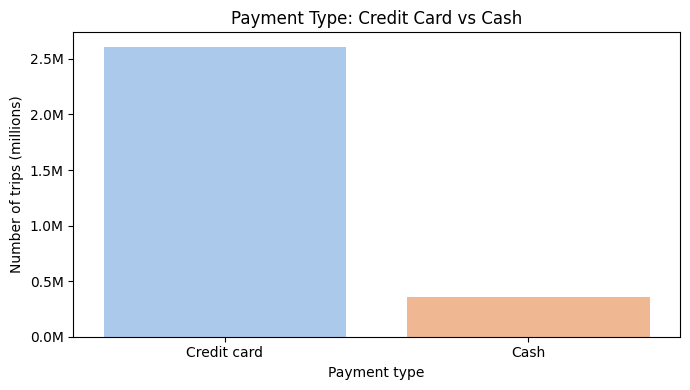

In [9]:
import matplotlib.ticker as mtick

plt.figure(figsize=(7, 4))
ax = sns.countplot(
    data=df[df['payment_type'].isin([1, 2])],
    x='payment_type',
    hue='payment_type',
    order=[1, 2],
    palette='pastel',
    legend=False
)

plt.xticks([0, 1], ['Credit card', 'Cash'])
plt.title('Payment Type: Credit Card vs Cash')
plt.xlabel('Payment type')
plt.ylabel('Number of trips (millions)')

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))

plt.tight_layout()
plt.show()

In [10]:
df['tip_amount'].describe() # solo tarjeta cred, calcula automaticamente

print(f"hay {(df['tip_amount'] < 0).sum()} propinas negativas. se pagó de menos, ajuste contable?")
print(f"el 50% deja entre {df['tip_amount'].quantile(0.25)} y {df['tip_amount'].quantile(0.75)} usd de propina, el promedio es de {df['tip_amount'].mean():.2f}")
print(f"la propina máxima fue de {df['tip_amount'].max():.2f} usd")

hay 40 propinas negativas. se pagó de menos, ajuste contable?
el 50% deja entre 0.0 y 3.95 usd de propina, el promedio es de 2.86
la propina máxima fue de 397.00 usd


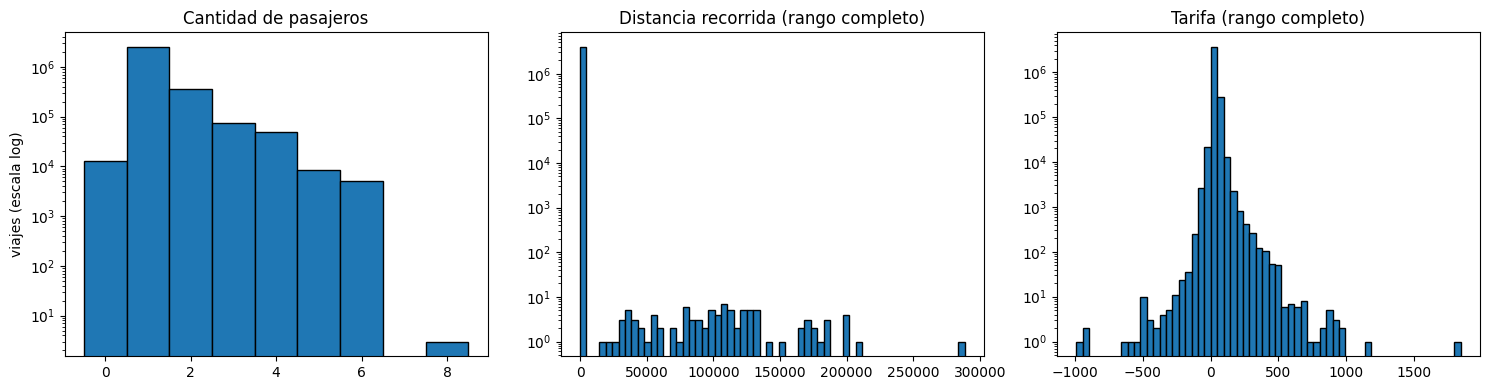

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Escala log en Y: permite ver los bins minoritarios de la cola
# (con escala lineal, los outliers extremos aplastan todo en una sola barra)
ax[0].hist(df['passenger_count'].dropna(), bins=np.arange(-0.5, 9.5, 1), edgecolor='black')
ax[0].set_title('Cantidad de pasajeros')
ax[0].set_yscale('log'); ax[0].set_ylabel('viajes (escala log)')

ax[1].hist(df['trip_distance'], bins=60, edgecolor='black')
ax[1].set_title('Distancia recorrida (rango completo)')
ax[1].set_yscale('log')

ax[2].hist(df['fare_amount'], bins=60, edgecolor='black')
ax[2].set_title('Tarifa (rango completo)')
ax[2].set_yscale('log')

plt.tight_layout()
plt.show()
# La escala log revela los outliers: distancias de hasta ~288 mil millas y
# tarifas negativas / de ~1.800 USD que en escala lineal eran invisibles.

In [12]:
def cuartiles(variable):
    Q1 = variable.quantile(0.25)
    Q2 = variable.quantile(0.50)  # Percentile 5-0 - Equivalente a la mediana
    Q3 = variable.quantile(0.75)
    return Q1, Q2, Q3

trip_distance_Q1, trip_distance_Q2, trip_distance_Q3 = cuartiles(df['trip_distance'])

print("Q1 (25%):", trip_distance_Q1, "millas")
print("Q2 (Mediana, 50%):", trip_distance_Q2, "millas")
print("Q3 (75%):", trip_distance_Q3, "millas")

trip_distance_IQR = trip_distance_Q3 - trip_distance_Q1
print("Rango intercuartil (IQR):", trip_distance_IQR, "millas")

Q1 (25%): 1.01 millas
Q2 (Mediana, 50%): 1.82 millas
Q3 (75%): 3.71 millas
Rango intercuartil (IQR): 2.7 millas


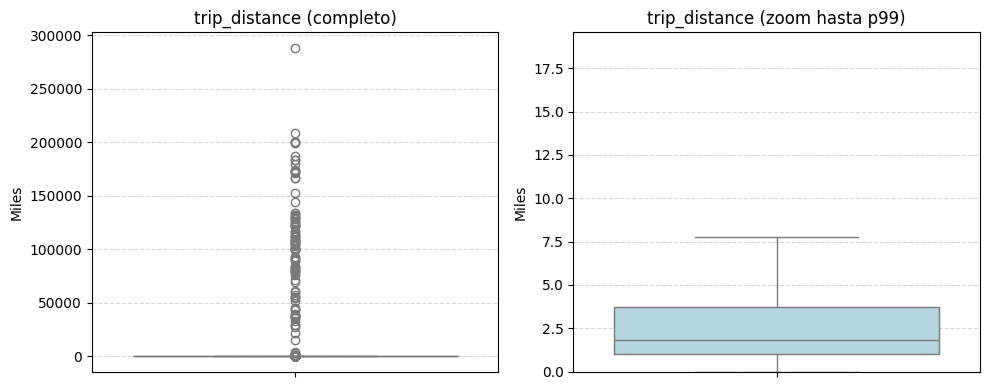

p99 de trip_distance: 19.58


In [13]:
trip_distance = df['trip_distance'].dropna()
trip_distance_pos = trip_distance[trip_distance >= 0]

p99 = trip_distance_pos.quantile(0.99)

fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

# Boxplot completo (sin ocultar outliers)
sns.boxplot(y=trip_distance_pos, color='lightblue', ax=ax[0])
ax[0].set_title('trip_distance (completo)')
ax[0].set_ylabel('Miles')
ax[0].grid(axis='y', ls='--', alpha=0.5)

# Boxplot con zoom hasta percentil 99
sns.boxplot(y=trip_distance_pos, color='lightblue', showfliers=False, ax=ax[1])
ax[1].set_ylim(0, p99)
ax[1].set_title('trip_distance (zoom hasta p99)')
ax[1].set_ylabel('Miles')
ax[1].grid(axis='y', ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f'p99 de trip_distance: {p99:.2f}')

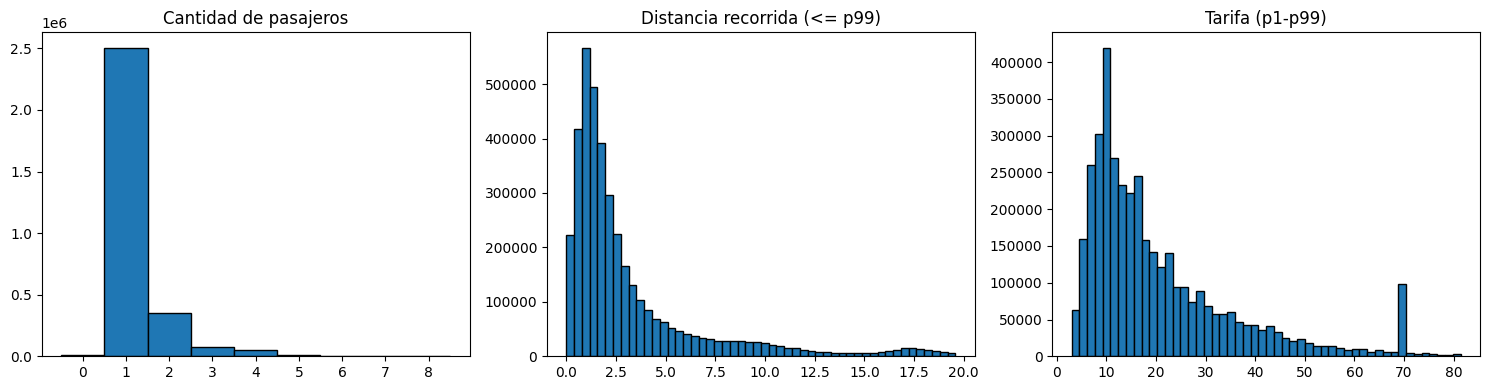

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# passenger_count como bins enteros
ax[0].hist(df['passenger_count'].dropna(), bins=np.arange(-0.5, 9.5, 1), edgecolor='black')
ax[0].set_title('Cantidad de pasajeros')
ax[0].set_xticks(range(0, 9))

# trip_distance sin extremos (p99)
d = df['trip_distance'].dropna()
d = d[(d >= 0) & (d <= d.quantile(0.99))]
ax[1].hist(d, bins=50, edgecolor='black')
ax[1].set_title('Distancia recorrida (<= p99)')

# fare_amount sin extremos (p1-p99)
f = df['fare_amount'].dropna()
f = f[(f >= f.quantile(0.01)) & (f <= f.quantile(0.99))]
ax[2].hist(f, bins=50, edgecolor='black')
ax[2].set_title('Tarifa (p1-p99)')

plt.tight_layout()
plt.show()

---

# Parte 1 — Exploración, visualización, problema de ML y preprocesamiento
_Responsable: **Varela, Gustavo (Gus)**_

Esta parte cubre: (1) exploración y comprensión de los datos, (2) técnicas de visualización, (3) planteo de un problema de ML supervisado y (4) preprocesamiento, limpieza y split del dataset.

> **Criterio transversal — estadística robusta.** Siguiendo el énfasis de la materia, a lo largo de todo el análisis priorizamos medidas robustas (mediana, IQR, MAD), detección de outliers por IQR / z-score robusto y correlaciones de Spearman y Kendall, porque el dataset tiene colas y errores extremos que distorsionan la media, el desvío estándar y la correlación de Pearson.

### Síntesis de hallazgos (resumen ejecutivo)

| # | Hallazgo | Implicancia para el trabajo |
|---|----------|------------------------------|
| 1 | **3.952.451 viajes × 20 variables** (marzo 2026), ~750 MB en RAM | Volumen sobrado para entrenar; exige técnicas eficientes |
| 2 | **23,93% de faltantes en 5 columnas**, 100% coincidentes con los viajes Flex Fare (`payment_type=0`) | Faltante **MAR/estructural** → imputable (mediana/moda del train) + bandera indicadora |
| 3 | Errores físicos: 1,24% de duraciones ≤ 0, distancias de hasta 288 mil millas, ~21 mil importes negativos, fechas de 2008 | La limpieza elimina solo lo imposible y **conserva el 95,2%** de los datos |
| 4 | Pearson duración~distancia = **0,00** en crudo vs **Spearman 0,79 / Kendall 0,63** | Los outliers destrozan las medidas clásicas → **estadística robusta** en todo el flujo |
| 5 | JFK: mediana **48 min** vs **11,7 min** tarifa estándar; velocidad mediana **8,2 mph a la tarde** vs **12,8 mph de madrugada** | Tarifa, zonas y hora son los predictores más prometedores de la duración |
| 6 | `tip_amount` solo se registra con tarjeta (propinas en efectivo = 0 siempre, **MNAR**) | Descarta a la propina como target → elegimos **regresión de la duración** |

In [15]:
# Configuración estética unificada para las visualizaciones de esta parte
sns.set_theme(style='whitegrid', context='notebook', palette='deep')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
                     'axes.labelsize': 11, 'axes.spines.top': False, 'axes.spines.right': False})

## 1. Exploración y comprensión de los datos

### 1.1 Estructura general del dataset

In [16]:
# Resumen estructural: nº de observaciones, nº de variables y tipos de datos
n_obs, n_vars = df.shape
print(f'Observaciones (viajes): {n_obs:,}')
print(f'Variables (columnas):  {n_vars}')
print(f'Memoria en RAM:        {df.memory_usage(deep=True).sum()/1e6:,.1f} MB')

tipos = (df.dtypes.astype(str)
           .replace({'int32':'entero','int64':'entero','float64':'flotante',
                     'object':'texto/categórica','datetime64[us]':'fecha-hora'}))
resumen_tipos = tipos.value_counts().rename('cantidad').to_frame()
resumen_tipos

Observaciones (viajes): 3,952,451
Variables (columnas):  20
Memoria en RAM:        726.4 MB


,cantidad
flotante,13
entero,4
fecha-hora,2
texto/categórica,1


In [17]:
# Clasificación semántica de las variables (más útil que el dtype crudo)
variables = {
    'numéricas continuas': ['trip_distance','fare_amount','extra','mta_tax','tip_amount',
                            'tolls_amount','improvement_surcharge','total_amount',
                            'congestion_surcharge','Airport_fee','cbd_congestion_fee'],
    'numéricas discretas': ['passenger_count'],
    'categóricas nominales': ['VendorID','RatecodeID','store_and_fwd_flag',
                              'payment_type','PULocationID','DOLocationID'],
    'temporales': ['tpep_pickup_datetime','tpep_dropoff_datetime'],
}
for tipo, cols in variables.items():
    print(f'{tipo:24s} ({len(cols)}): {cols}')

numéricas continuas      (11): ['trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee']
numéricas discretas      (1): ['passenger_count']
categóricas nominales    (6): ['VendorID', 'RatecodeID', 'store_and_fwd_flag', 'payment_type', 'PULocationID', 'DOLocationID']
temporales               (2): ['tpep_pickup_datetime', 'tpep_dropoff_datetime']


**Interpretación.** El dataset tiene **3.952.451 viajes** y **20 variables**. Conviven variables temporales (pickup/dropoff), numéricas de importe (la mayoría componentes de la tarifa), una numérica discreta (`passenger_count`) y varias categóricas que vienen codificadas como números (`VendorID`, `RatecodeID`, `payment_type`, `PULocationID`, `DOLocationID`). Es clave tratar a estas últimas como **categóricas**, no como números, porque su magnitud no tiene sentido aritmético (la zona 238 no es 'mayor' que la 90).

### 1.2 Estadística descriptiva — robusta vs no robusta

Comparamos medidas clásicas (media, desvío) contra medidas robustas (mediana, IQR, MAD) para anticipar el impacto de los outliers.

In [18]:
def mad(x):
    """Desviación absoluta mediana (Median Absolute Deviation), medida robusta de dispersión."""
    x = x.dropna()
    return (x - x.median()).abs().median()

num_cols = ['trip_distance','fare_amount','tip_amount','total_amount','passenger_count']
tabla = pd.DataFrame({
    'media':   [df[c].mean()   for c in num_cols],
    'mediana': [df[c].median() for c in num_cols],
    'std':     [df[c].std()    for c in num_cols],
    'IQR':     [df[c].quantile(.75)-df[c].quantile(.25) for c in num_cols],
    'MAD':     [mad(df[c])     for c in num_cols],
    'min':     [df[c].min()    for c in num_cols],
    'max':     [df[c].max()    for c in num_cols],
}, index=num_cols).round(2)
tabla

,media,mediana,std,IQR,MAD,min,max
trip_distance,5.98,1.82,581.05,2.70,1.02,0.00,288381.68
fare_amount,21.33,15.60,18.69,16.80,7.00,-990.00,1843.30
tip_amount,2.86,2.11,3.91,3.95,2.11,-75.75,397.00
total_amount,30.10,23.40,22.41,17.68,7.49,-1022.46,1850.55
passenger_count,1.23,1.00,0.63,0.00,0.00,0.00,8.00


**Interpretación.** La brecha entre **media y mediana** y entre **std e IQR/MAD** es enorme: por ejemplo `trip_distance` tiene mediana ~1,8 millas pero un máximo de **288.381 millas** (físicamente imposible), y `fare_amount` llega a ~1.843 USD. La media y el desvío están **inflados por valores extremos**, mientras que mediana, IQR y MAD se mantienen estables. Esto justifica usar estadística robusta en el resto del trabajo.

### 1.3 Valores faltantes y su tipo (MCAR / MAR / MNAR)

In [19]:
nulos = df.isna().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
tab_nulos = pd.DataFrame({'faltantes': nulos, 'porcentaje': (100*nulos/len(df)).round(2)})
tab_nulos

,faltantes,porcentaje
passenger_count,945748,23.93
RatecodeID,945748,23.93
store_and_fwd_flag,945748,23.93
congestion_surcharge,945748,23.93
Airport_fee,945748,23.93


In [20]:
# ¿Los faltantes coinciden entre sí y con algún valor observado?
cols_nan = ['passenger_count','RatecodeID','store_and_fwd_flag',
            'congestion_surcharge','Airport_fee']
mask = df['passenger_count'].isna()
print(f'Filas con passenger_count nulo: {mask.sum():,} ({100*mask.mean():.2f}%)')
print('¿Las 5 columnas faltan en las MISMAS filas?',
      all((df[c].isna() == mask).all() for c in cols_nan))
print()
# Relación de esos faltantes con payment_type
print('payment_type de las filas con faltantes:')
print(df.loc[mask, 'payment_type'].value_counts(normalize=True).mul(100).round(2))
print()
print('De los viajes con payment_type==0 (Flex Fare), %% con datos faltantes:',
      round(100*df.loc[df['payment_type']==0,'passenger_count'].isna().mean(),2))

Filas con passenger_count nulo: 945,748 (23.93%)
¿Las 5 columnas faltan en las MISMAS filas? True

payment_type de las filas con faltantes:
payment_type
0    100.0
Name: proportion, dtype: float64

De los viajes con payment_type==0 (Flex Fare), %% con datos faltantes: 100.0


**Interpretación — tipo de faltantes.** Las cinco columnas con nulos faltan **exactamente en las mismas 945.748 filas (23,93%)**, y esas filas son **el 100% de los viajes con `payment_type == 0` (Flex Fare)**. La ausencia no es aleatoria: depende de una variable **observada** (el canal/tipo de viaje Flex Fare, asociado a otro proveedor).

- **No es MCAR**: si fuera completamente al azar, los nulos se repartirían entre todos los tipos de pago, no se concentrarían en uno.
- **Es MAR / faltante estructural**: la probabilidad de faltante se explica por una variable observada (`payment_type`/canal Flex Fare). Conociendo esa variable, el faltante es predecible y, por lo tanto, **imputable** (con mediana/moda del train o con un indicador de faltante).

En cambio, los **ceros de `tip_amount` en pagos en efectivo** son un caso distinto, más cercano a **MNAR**: la propina en efectivo existe en la realidad pero **nunca se registra** (lo aclara el diccionario de datos). El valor faltante depende del propio valor no observado.

### 1.4 Errores y valores imposibles

Derivamos la **duración del viaje** (que además será nuestro target) y buscamos inconsistencias físicas/lógicas.

In [21]:
# Duración del viaje en minutos = dropoff - pickup
df['duration_min'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds()/60

errores = {
    'duración <= 0 (dropoff <= pickup)':      (df['duration_min'] <= 0).sum(),
    'duración > 180 min (>3 h)':              (df['duration_min'] > 180).sum(),
    'trip_distance == 0':                     (df['trip_distance'] == 0).sum(),
    'trip_distance > 100 millas':             (df['trip_distance'] > 100).sum(),
    'fare_amount < 0':                        (df['fare_amount'] < 0).sum(),
    'total_amount < 0':                       (df['total_amount'] < 0).sum(),
    'tip_amount < 0':                         (df['tip_amount'] < 0).sum(),
    'passenger_count == 0':                   (df['passenger_count'] == 0).sum(),
    'pickup fuera de marzo 2026':             (~df['tpep_pickup_datetime'].between('2026-03-01','2026-03-31 23:59:59')).sum(),
}
err = pd.DataFrame({'casos': pd.Series(errores)})
err['porcentaje'] = (100*err['casos']/len(df)).round(3)
print('Rango de fechas de pickup:', df['tpep_pickup_datetime'].min(), '->', df['tpep_pickup_datetime'].max())
err

Rango de fechas de pickup: 2008-12-31 23:03:20 -> 2026-04-01 00:06:25


,casos,porcentaje
duración <= 0 (dropoff <= pickup),49133,1.243
duración > 180 min (>3 h),1181,0.030
trip_distance == 0,121210,3.067
trip_distance > 100 millas,161,0.004
fare_amount < 0,20724,0.524
total_amount < 0,21305,0.539
tip_amount < 0,40,0.001
passenger_count == 0,12967,0.328
pickup fuera de marzo 2026,19,0.000


**Interpretación.** Aparecen errores claros: **49.133 viajes (1,24%) con duración ≤ 0** (el dropoff ocurre antes que el pickup), duraciones de hasta **127 horas**, **121.210 viajes con distancia 0**, importes **negativos** en `fare_amount` y `total_amount` (≈21 mil cada uno, típicamente reembolsos/ajustes o disputas), y timestamps fuera de rango (el mínimo es de 2008). Son inconsistencias que hay que **corregir o eliminar** en la limpieza.

#### Caso de estudio: ¿los viajes con `passenger_count == 0` son mensajería?

Hipótesis del grupo: los viajes "sin pasajeros" podrían ser traslados de paquetes (servicio de courier). Antecedente real: TLC organizó entregas con conductores licenciados durante la pandemia (programa de emergencia *GetFoodNYC*, 2020), pero era delivery de comida y no hay evidencia de un programa vigente en 2026. Contrastamos la hipótesis contra los datos comparando los ~13 mil viajes con cero pasajeros declarados contra el resto.

In [22]:
# ¿Se comportan distinto los viajes con 0 pasajeros declarados?
zp    = df[df['passenger_count'] == 0]
resto = df[df['passenger_count'] >= 1]
print(f'Viajes con 0 pasajeros declarados: {len(zp):,} ({100*len(zp)/len(df):.2f}% del total)')

comp = pd.DataFrame({
    'cero pasajeros': [zp['VendorID'].eq(1).mean()*100,  zp['tip_amount'].eq(0).mean()*100,
                       zp['tip_amount'].median(),         zp['trip_distance'].median(),
                       zp['duration_min'].median(),       zp['RatecodeID'].eq(5).mean()*100,
                       zp['store_and_fwd_flag'].eq('Y').mean()*100],
    'resto':          [resto['VendorID'].eq(1).mean()*100, resto['tip_amount'].eq(0).mean()*100,
                       resto['tip_amount'].median(),       resto['trip_distance'].median(),
                       resto['duration_min'].median(),     resto['RatecodeID'].eq(5).mean()*100,
                       resto['store_and_fwd_flag'].eq('Y').mean()*100],
}, index=['% proveedor CMT (VendorID=1)', '% sin propina', 'propina mediana (USD)',
          'distancia mediana (millas)', 'duración mediana (min)',
          '% tarifa negociada (Rate=5)', '% store-and-forward']).round(2)
comp

Viajes con 0 pasajeros declarados: 12,967 (0.33% del total)


,cero pasajeros,resto
% proveedor CMT (VendorID=1),92.83,21.37
% sin propina,20.06,21.74
propina mediana (USD),2.80,2.95
distancia mediana (millas),1.40,1.70
duración mediana (min),10.62,12.35
% tarifa negociada (Rate=5),1.53,1.10
% store-and-forward,0.89,0.16


**Veredicto: artefacto de registro, no mensajería.** Dos evidencias lo definen:

1. **Concentración en un solo proveedor**: el **92,8% de los viajes con cero pasajeros proviene de CMT (VendorID=1)**, que solo origina el 21,4% del resto de los viajes. Un servicio de mensajería real no tendría motivo para concentrarse en un proveedor de *software de taxímetro*; un default de carga del sistema/conductor, sí.
2. **Comportamiento idéntico a un viaje con pasajero**: propinan igual (mediana 2,80 vs 2,95 USD; ~20% sin propina en ambos grupos), recorren distancias y duraciones similares y casi no usan tarifa negociada. Un traslado de paquetes debería verse distinto (sin propina de tarjeta a bordo, tarifas negociadas).

Además, `tip_amount == 0` tampoco implica "sin pasajero": el diccionario TLC aclara que las propinas **en efectivo no se registran**, así que el cero es esperable en todo pago cash.

**Decisión de preprocesamiento**: los `passenger_count == 0` se tratan como **dato de baja confiabilidad en esa columna** (se imputan como 1, la moda) pero **el viaje se conserva**, porque sus tiempos, distancias y zonas son plausibles y válidos para el problema de duración. No hay evidencia para etiquetarlos como courier ni para eliminarlos.

### 1.5 Detección de outliers — IQR y z-score robusto (MAD)

Aplicamos las dos técnicas vistas en clase. Para el z-score usamos la versión **robusta** (basada en mediana y MAD) en lugar de la clásica (media ± 3·std), porque la media y el std ya vimos que están contaminados.

In [23]:
def outliers_iqr(s, k=1.5):
    s = s.dropna()
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    lo, hi = q1 - k*iqr, q3 + k*iqr
    return lo, hi, ((s < lo) | (s > hi)).sum(), len(s)

def outliers_z_robusto(s, thr=3.5):
    s = s.dropna()
    med = s.median()
    mad_ = (s - med).abs().median()
    if mad_ == 0:
        return None, 0, len(s)
    z = 0.6745*(s - med)/mad_   # z-score robusto (Iglewicz-Hoaglin)
    return thr, (z.abs() > thr).sum(), len(s)

for c in ['duration_min','trip_distance','fare_amount']:
    lo, hi, n_iqr, n = outliers_iqr(df[c])
    _, n_z, _ = outliers_z_robusto(df[c])
    print(f'{c:14s} | IQR -> límites [{lo:8.2f}, {hi:8.2f}]  outliers={n_iqr:>8,} ({100*n_iqr/n:5.2f}%)'
          f'  | z-robusto>3.5 -> {n_z:>8,} ({100*n_z/n:5.2f}%)')

duration_min   | IQR -> límites [  -11.89,    41.11]  outliers= 239,308 ( 6.05%)  | z-robusto>3.5 ->  192,165 ( 4.86%)
trip_distance  | IQR -> límites [   -3.04,     7.76]  outliers= 457,715 (11.58%)  | z-robusto>3.5 ->  505,298 (12.78%)


fare_amount    | IQR -> límites [  -15.20,    52.00]  outliers= 271,353 ( 6.87%)  | z-robusto>3.5 ->  272,448 ( 6.89%)


**Interpretación.** El método **IQR** marca como outliers ~6% de las duraciones, ~11,6% de las distancias y ~6,9% de las tarifas. No todos son errores: muchos son viajes legítimamente largos (cola derecha real del negocio de taxis). La estrategia, por eso, no será borrar todo lo que cae fuera del IQR, sino **distinguir errores imposibles (que se eliminan) de outliers plausibles (que se acotan/winsorizan)** en la etapa de preprocesamiento.

## 2. Aplicación de técnicas de visualización

Elegimos el gráfico según el tipo de variable: histogramas/boxplots para numéricas, countplots para categóricas, series y heatmap para lo temporal, y matrices de correlación para relaciones entre numéricas.

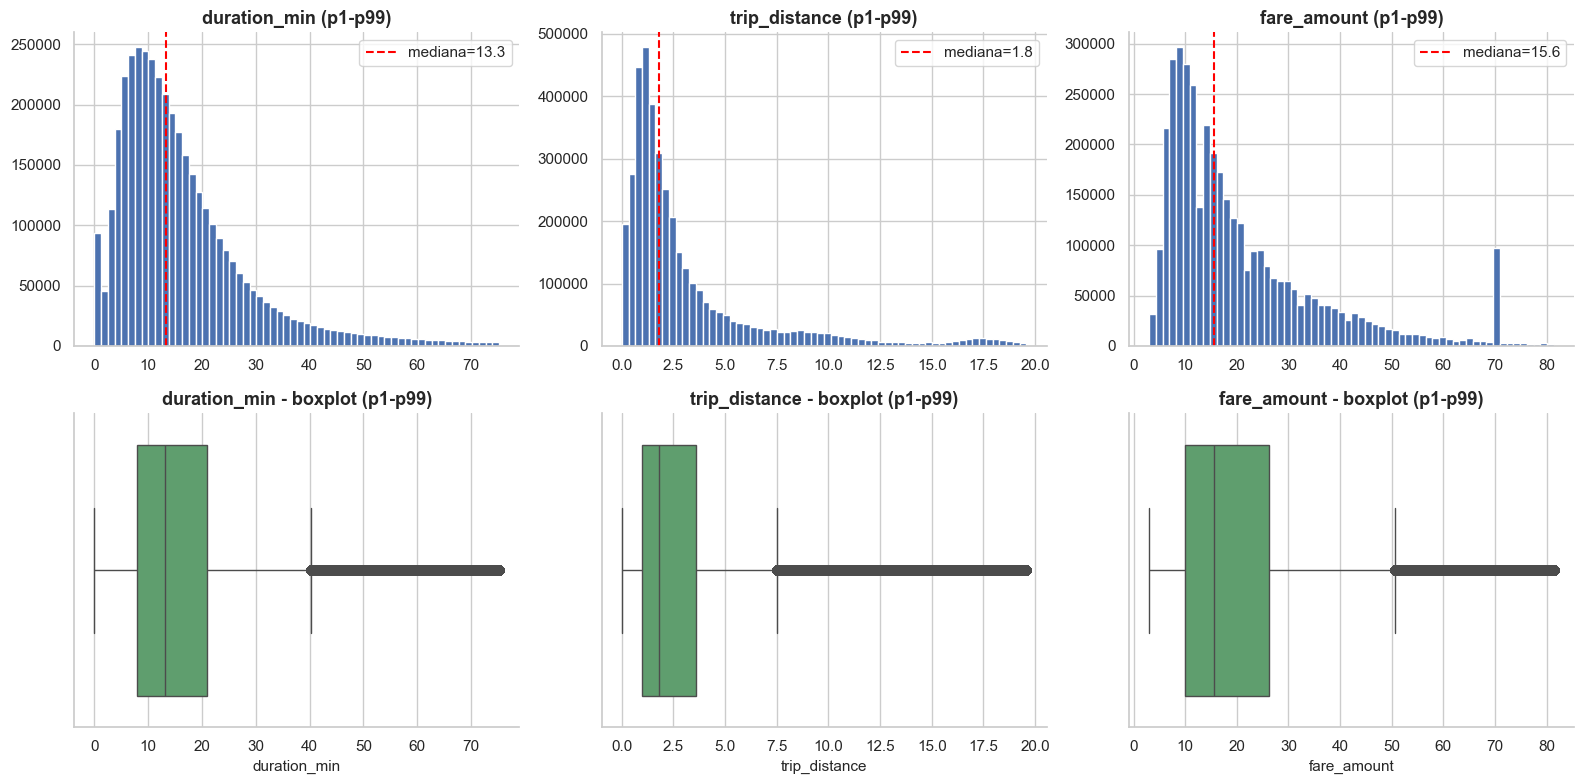

In [24]:
# 2.1 Distribución de variables numéricas clave (recortadas a p1-p99 para que el outlier no aplaste el gráfico)
vis_cols = ['duration_min','trip_distance','fare_amount']
fig, ax = plt.subplots(2, 3, figsize=(16, 8))
for j, c in enumerate(vis_cols):
    s = df[c]
    s_clip = s[(s >= s.quantile(.01)) & (s <= s.quantile(.99))]
    ax[0, j].hist(s_clip, bins=60, color='#4C72B0', edgecolor='white')
    ax[0, j].axvline(s.median(), color='red', ls='--', label=f'mediana={s.median():.1f}')
    ax[0, j].set_title(f'{c} (p1-p99)'); ax[0, j].legend()
    sns.boxplot(x=s_clip, ax=ax[1, j], color='#55A868')
    ax[1, j].set_title(f'{c} - boxplot (p1-p99)')
plt.tight_layout(); plt.show()

**Interpretación.** Las tres variables tienen **distribución asimétrica a derecha** (sesgo positivo): la mayoría de los viajes son cortos/baratos y hay una cola larga de viajes largos. La mediana (línea roja) queda muy por debajo de la cola, confirmando por qué la media no es representativa.

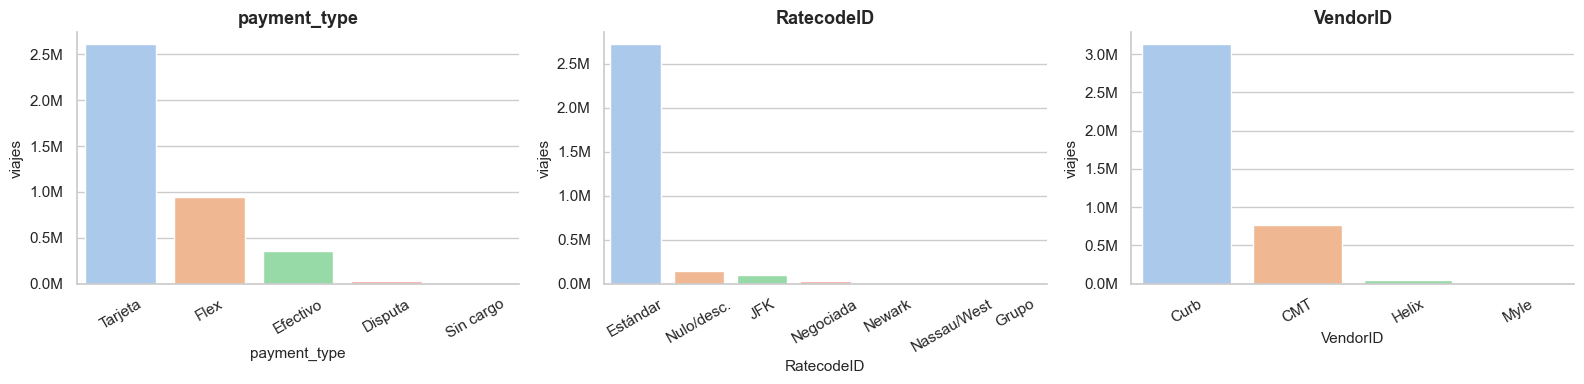

In [25]:
# 2.2 Variables categóricas: countplots con etiquetas legibles
import matplotlib.ticker as mtick
mapas = {
    'payment_type': {0:'Flex',1:'Tarjeta',2:'Efectivo',3:'Sin cargo',4:'Disputa',5:'Desc.',6:'Anulado'},
    'RatecodeID':   {1:'Estándar',2:'JFK',3:'Newark',4:'Nassau/West',5:'Negociada',6:'Grupo',99:'Nulo/desc.'},
    'VendorID':     {1:'CMT',2:'Curb',6:'Myle',7:'Helix'},
}
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for j, c in enumerate(mapas):
    vc = df[c].map(mapas[c]).value_counts()
    sns.barplot(x=vc.index, y=vc.values, hue=vc.index, ax=ax[j], palette='pastel', legend=False)
    ax[j].set_title(c); ax[j].set_ylabel('viajes')
    ax[j].tick_params(axis='x', rotation=30)
    ax[j].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
plt.tight_layout(); plt.show()

**Interpretación.** Predomina el pago con **tarjeta (66%)**, seguido de Flex Fare (24%) y efectivo (9%). En tarifa, casi todo es **rate estándar**; el proveedor **Curb (VendorID=2) concentra ~79%** de los viajes. Son variables muy desbalanceadas, dato a tener en cuenta si se usaran como features categóricas.

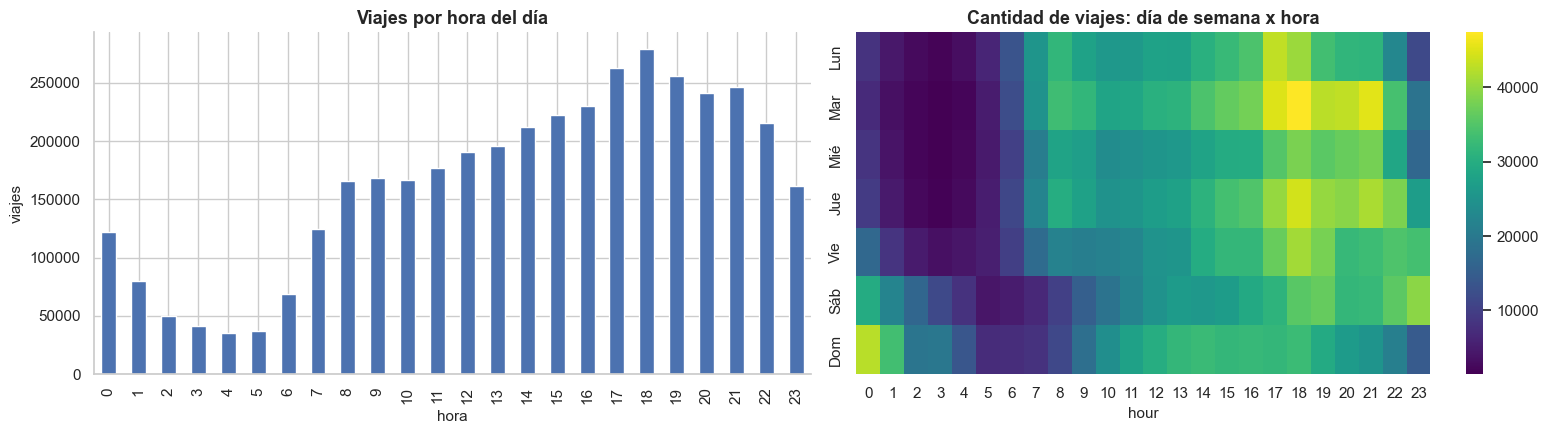

In [26]:
# 2.3 Patrones temporales: viajes por hora y mapa de calor hora x día de semana
df['hour'] = df['tpep_pickup_datetime'].dt.hour
df['dow']  = df['tpep_pickup_datetime'].dt.dayofweek  # 0=Lunes
dias = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
fig, ax = plt.subplots(1, 2, figsize=(16, 4.5))
df.groupby('hour').size().plot(kind='bar', ax=ax[0], color='#4C72B0')
ax[0].set_title('Viajes por hora del día'); ax[0].set_xlabel('hora'); ax[0].set_ylabel('viajes')
piv = df.pivot_table(index='dow', columns='hour', values='duration_min', aggfunc='size')
piv.index = dias
sns.heatmap(piv, cmap='viridis', ax=ax[1])
ax[1].set_title('Cantidad de viajes: día de semana x hora')
plt.tight_layout(); plt.show()

**Interpretación.** La demanda tiene un patrón diario marcado: **mínimo a las ~4 a.m.** y **pico a las ~18 h** (salida laboral). El heatmap muestra además el pico nocturno de los fines de semana (viernes/sábado de madrugada). La **hora** y el **día de semana** son, por lo tanto, candidatos fuertes como features para predecir la duración (el tráfico depende del horario).

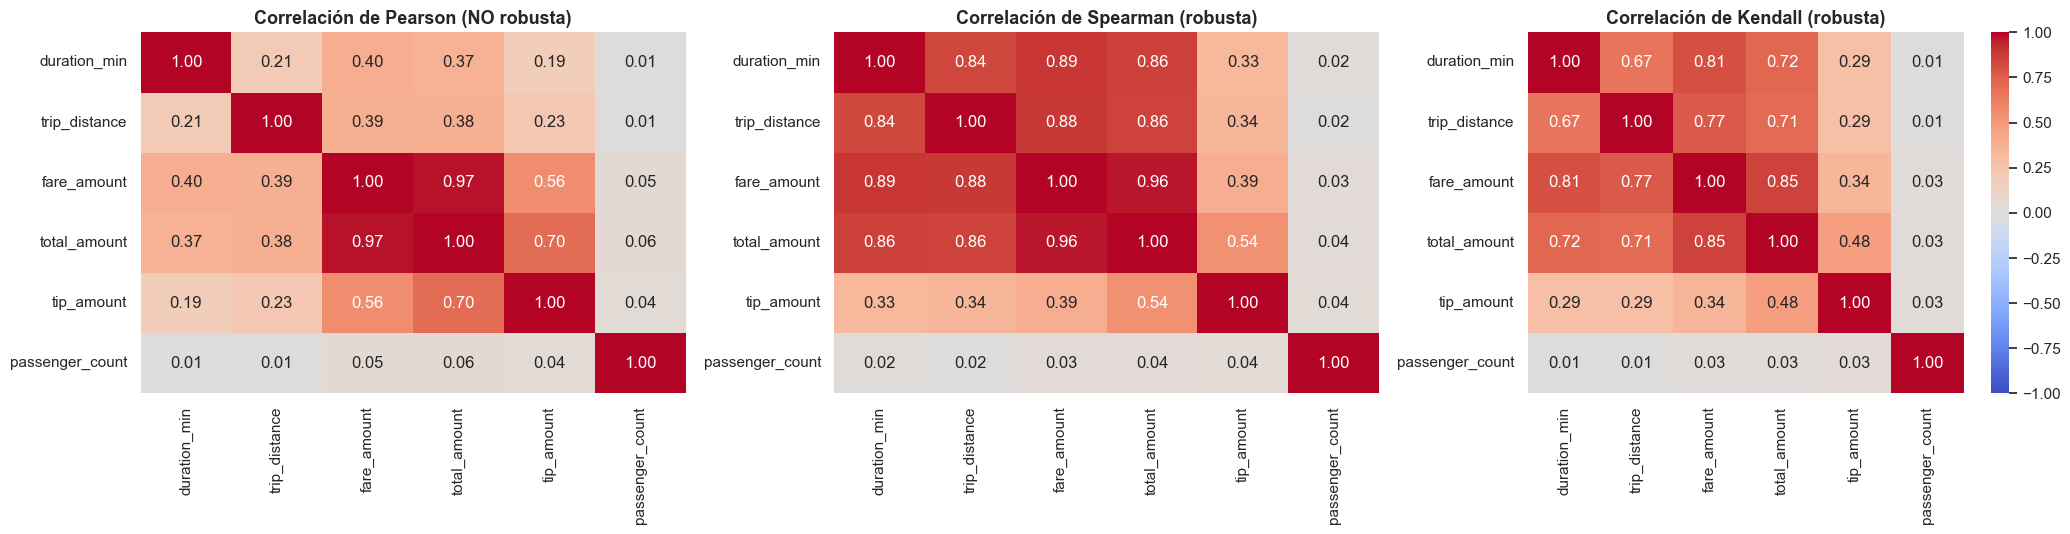

In [27]:
# 2.4 Relación entre numéricas: Pearson vs Spearman vs Kendall
corr_cols = ['duration_min','trip_distance','fare_amount','total_amount','tip_amount','passenger_count']
samp = df[corr_cols].dropna().sample(200_000, random_state=0)
metodos = [('pearson','Pearson (NO robusta)'), ('spearman','Spearman (robusta)'), ('kendall','Kendall (robusta)')]
fig, ax = plt.subplots(1, 3, figsize=(21, 5.5))
for j, (m, titulo) in enumerate(metodos):
    sns.heatmap(samp.corr(method=m), annot=True, fmt='.2f', cmap='coolwarm',
                center=0, vmin=-1, vmax=1, ax=ax[j], cbar=(j == 2))
    ax[j].set_title(f'Correlación de {titulo}')
plt.tight_layout(); plt.show()

**Interpretación — caso de estadística robusta.** La **Pearson** entre `duration_min` y `trip_distance` da prácticamente **0** sobre los datos crudos, lo cual es absurdo (a más distancia, más duración). El culpable son los outliers extremos (distancias de cientos de miles de millas): Pearson asume relación lineal y es muy sensible a valores extremos.

Las dos medidas **robustas** vistas en clase revelan la relación real:

- **Spearman** (correlación de rangos, detecta relación monótona): **0,79** duración–distancia y **0,85** duración–tarifa.
- **Kendall** (concordancia de pares, también robusta): **0,63** duración–distancia y **0,72** duración–tarifa.

Kendall suele dar valores absolutos menores que Spearman para la misma asociación (compara pares concordantes/discordantes en vez de correlacionar rangos), pero ambas cuentan la misma historia: la asociación es **fuerte y positiva**, y Pearson la ocultaba por completo. Ante colas pesadas, conviene apoyarse en medidas robustas.

Otro hallazgo: `fare_amount` y `total_amount` están correlacionadas a **0,97** (casi redundantes), y ambas se conocen recién **al finalizar** el viaje → riesgo de **fuga de información** si se usan para predecir la duración.

### 2.5 Relación numérica × categórica: violin plots

El violin plot combina un **boxplot** con la **estimación de densidad (KDE)**: muestra mediana, cuartiles y, además, la *forma* completa de la distribución por categoría. (El swarmplot, también visto en clase, no es viable acá: con 3,9M de puntos el gráfico sería ilegible y carísimo de renderizar; es una técnica para muestras chicas.)

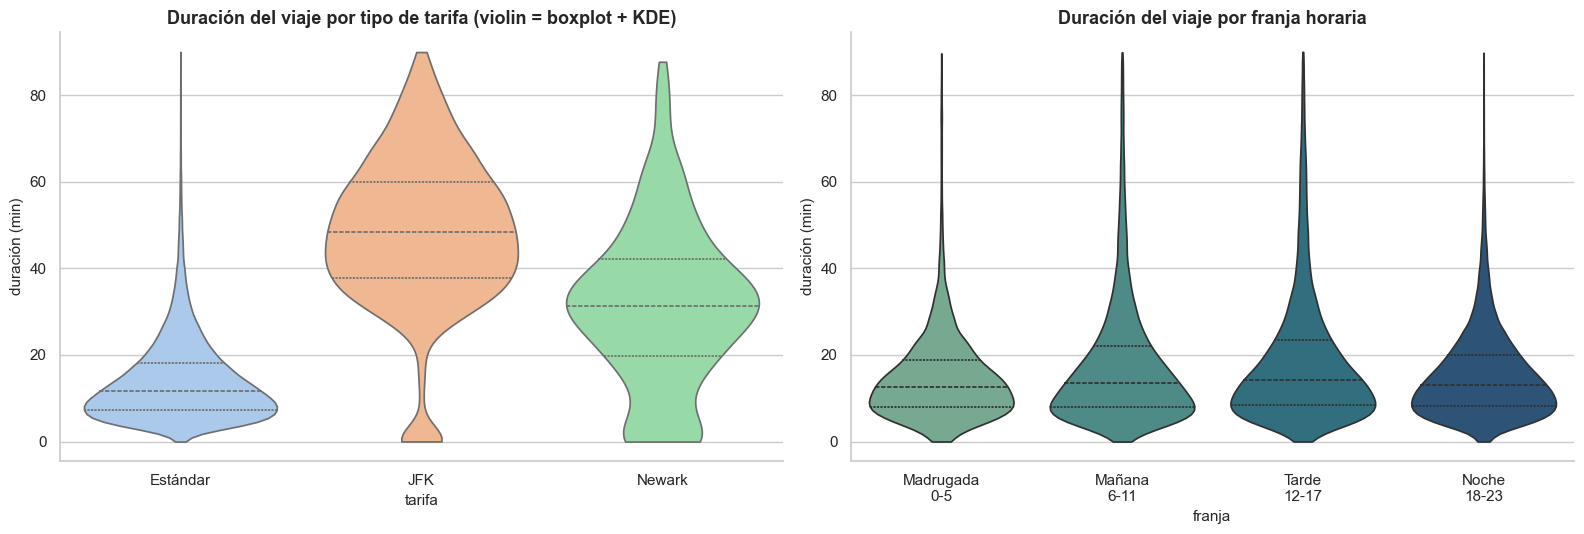

In [28]:
# Violin plots: duración según tipo de tarifa y según franja horaria
sub = df[(df['duration_min'] > 0) & (df['duration_min'] <= 90)].copy()
sub['tarifa'] = sub['RatecodeID'].map({1:'Estándar', 2:'JFK', 3:'Newark'})
sub['franja'] = pd.cut(sub['hour'], bins=[-1,5,11,17,23],
                       labels=['Madrugada\n0-5','Mañana\n6-11','Tarde\n12-17','Noche\n18-23'])

muestra = sub.dropna(subset=['tarifa']).sample(150_000, random_state=0)
fig, ax = plt.subplots(1, 2, figsize=(16, 5.5))
sns.violinplot(data=muestra, x='tarifa', y='duration_min', hue='tarifa', order=['Estándar','JFK','Newark'],
               palette='pastel', inner='quartile', cut=0, ax=ax[0], legend=False)
ax[0].set_title('Duración del viaje por tipo de tarifa (violin = boxplot + KDE)')
ax[0].set_ylabel('duración (min)')
sns.violinplot(data=sub.sample(150_000, random_state=0), x='franja', y='duration_min', hue='franja',
               palette='crest', inner='quartile', cut=0, ax=ax[1], legend=False)
ax[1].set_title('Duración del viaje por franja horaria')
ax[1].set_ylabel('duración (min)')
plt.tight_layout(); plt.show()

**Interpretación.** El violín izquierdo expone la mayor diferencia de todo el EDA: los viajes con tarifa **JFK tienen mediana de ~48 min** (distribución ancha y simétrica alrededor de la mediana) contra **~11,7 min de la tarifa estándar** (concentrada abajo, con cola superior). **Newark queda en el medio (~32 min)**. El tipo de tarifa codifica implícitamente el destino aeropuerto → es un predictor potente de la duración. (Contexto: **JFK** es el aeropuerto internacional, en Queens, a ~17 millas del centro de Manhattan; **Newark** está en New Jersey, cruzando el río Hudson — ambos con tarifas especiales de taxímetro, distintas de la tarifa estándar por reloj.)

Por franja horaria las **medianas son parecidas (12,4–14,2 min)** pero la *forma* cambia: la **tarde (12–17 h)** tiene el cuerpo más desplazado hacia arriba y cola más pesada (tráfico), mientras la madrugada se concentra en viajes cortos. Esto sugiere que la hora aporta señal sobre la duración más allá de la distancia — algo que un boxplot solo insinuaría y el violín hace visible.

In [29]:
# Evidencia cuantitativa del efecto tráfico: velocidad efectiva mediana por franja
vel = sub[(sub['duration_min'] > 1) & (sub['trip_distance'] > 0) & (sub['trip_distance'] <= 30)].copy()
vel['vel_mph'] = vel['trip_distance'] / (vel['duration_min']/60)
vel = vel[vel['vel_mph'] < 60]  # descarta velocidades físicamente imposibles
vel.groupby('franja', observed=True)['vel_mph'].median().round(1).rename('velocidad mediana (mph)').to_frame()

,velocidad mediana (mph)
franja,
Madrugada\n0-5,12.8
Mañana\n6-11,9.4
Tarde\n12-17,8.2
Noche\n18-23,10.0


**La evidencia del tráfico.** La velocidad efectiva mediana cae de **12,8 mph en la madrugada a 8,2 mph en la tarde** (−36%): un mismo trayecto tarda ~50% más en hora pico. Esto confirma cuantitativamente lo que los violines insinuaban: la **hora del día aporta señal propia, independiente de la distancia**, y justifica las features horarias del modelo.

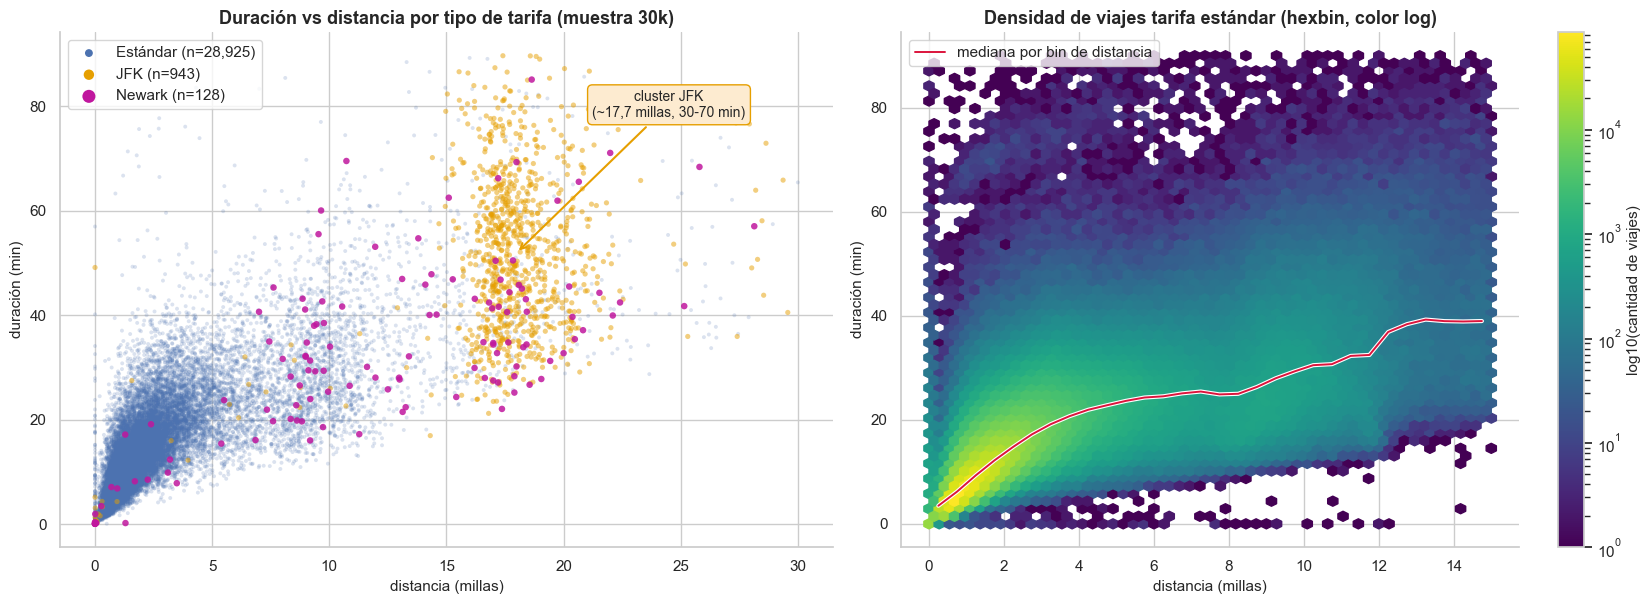

In [30]:
# Relación multivariada (slides clase 2): dos numéricas + una categórica como hue
fig, ax = plt.subplots(1, 2, figsize=(17, 6.2))

# Panel izquierdo: scatter por capas -> la clase mayoritaria de fondo y las minoritarias
# encima, con colores bien separados en tono (azul / naranja / magenta)
muestra2 = sub.dropna(subset=['tarifa']).sample(30_000, random_state=1)
muestra2 = muestra2[muestra2['trip_distance'] <= 30]
estilos = {  # color, alpha, tamaño: más opacas y grandes las clases con menos puntos
    'Estándar': ('#4C72B0', 0.20,  8),
    'JFK':      ('#E69F00', 0.50, 14),
    'Newark':   ('#C0179E', 0.85, 22),
}
for tarifa, (color, alpha, s) in estilos.items():
    g = muestra2[muestra2['tarifa'] == tarifa]
    ax[0].scatter(g['trip_distance'], g['duration_min'], c=color, alpha=alpha, s=s,
                  label=f'{tarifa} (n={len(g):,})', edgecolors='none')
ax[0].annotate('cluster JFK\n(~17,7 millas, 30-70 min)', xy=(18, 52), xytext=(24.5, 78),
               fontsize=10, ha='center',
               arrowprops=dict(arrowstyle='->', color='#E69F00', lw=1.5),
               bbox=dict(boxstyle='round,pad=0.35', fc='#FDEBD0', ec='#E69F00'))
ax[0].set_title('Duración vs distancia por tipo de tarifa (muestra 30k)')
ax[0].set_xlabel('distancia (millas)'); ax[0].set_ylabel('duración (min)')
leg = ax[0].legend(loc='upper left', markerscale=2)
for lh in leg.legend_handles: lh.set_alpha(1)

# Panel derecho: hexbin con color logarítmico -> densidad real, sin overplotting
est = sub[(sub['tarifa'] == 'Estándar') & (sub['trip_distance'] <= 15)]
hb = ax[1].hexbin(est['trip_distance'], est['duration_min'], gridsize=55, bins='log', cmap='viridis')
# tendencia central robusta: mediana de duración por bin de distancia
bins_d = pd.cut(est['trip_distance'], bins=np.arange(0, 15.5, 0.5))
med = est.groupby(bins_d, observed=True)['duration_min'].median()
centros = [iv.mid for iv in med.index]
ax[1].plot(centros, med.values, color='white', lw=3)
ax[1].plot(centros, med.values, color='crimson', lw=1.4, label='mediana por bin de distancia')
fig.colorbar(hb, ax=ax[1], label='log10(cantidad de viajes)')
ax[1].set_title('Densidad de viajes tarifa estándar (hexbin, color log)')
ax[1].set_xlabel('distancia (millas)'); ax[1].set_ylabel('duración (min)')
ax[1].legend(loc='upper left')
plt.tight_layout(); plt.show()

**Interpretación.** El scatter (izquierda) confirma la relación **monótona positiva** entre distancia y duración que Pearson no detectaba, y el **cluster JFK** queda anotado: viajes de ~17,7 millas con 30–70 min, la firma del trayecto Manhattan–aeropuerto.

El scatter, sin embargo, sufre **overplotting**: con tantos puntos superpuestos no se distingue dónde está la masa. El **hexbin con escala de color logarítmica** (derecha) lo resuelve y muestra que el grueso del negocio son viajes de **1–3 millas y 5–20 minutos**. La curva roja —**mediana de duración por bin de distancia**, otra aplicación de estadística robusta— crece de forma sostenida y casi lineal, pero la dispersión vertical alrededor de ella (un mismo trayecto puede tardar el doble según el tráfico) es exactamente la variabilidad que el modelo deberá capturar con las features horarias y de zona.

### 2.6 Dimensión espacial: zonas TLC con nombres reales

`PULocationID`/`DOLocationID` son códigos. Para interpretarlos los cruzamos con la **tabla oficial de zonas de TLC** (`taxi_zone_lookup.csv`, agregada al repo), que mapea cada ID a su barrio y borough.

> **Mini-guía geográfica para leer los resultados.** Manhattan se divide informalmente en **Downtown** (extremo sur de la isla: Financial District, TriBeCa, SoHo, los Villages — finanzas y vida nocturna), **Midtown** (centro: Times Square, Penn Station, Grand Central — oficinas, comercio, turismo y los grandes nodos de transporte) y **Uptown** (norte: Upper East / Upper West Side — residencial de alto poder adquisitivo; más al norte, Harlem). Los tres aeropuertos del área: **JFK** (Queens, el internacional principal, a ~17 millas del centro), **LaGuardia / LGA** (Queens, mayormente vuelos domésticos, a ~9 millas) y **Newark / EWR** (en New Jersey, cruzando el río Hudson: queda *fuera* de NYC y por eso el taxímetro le aplica una tarifa especial, `RatecodeID=3`).

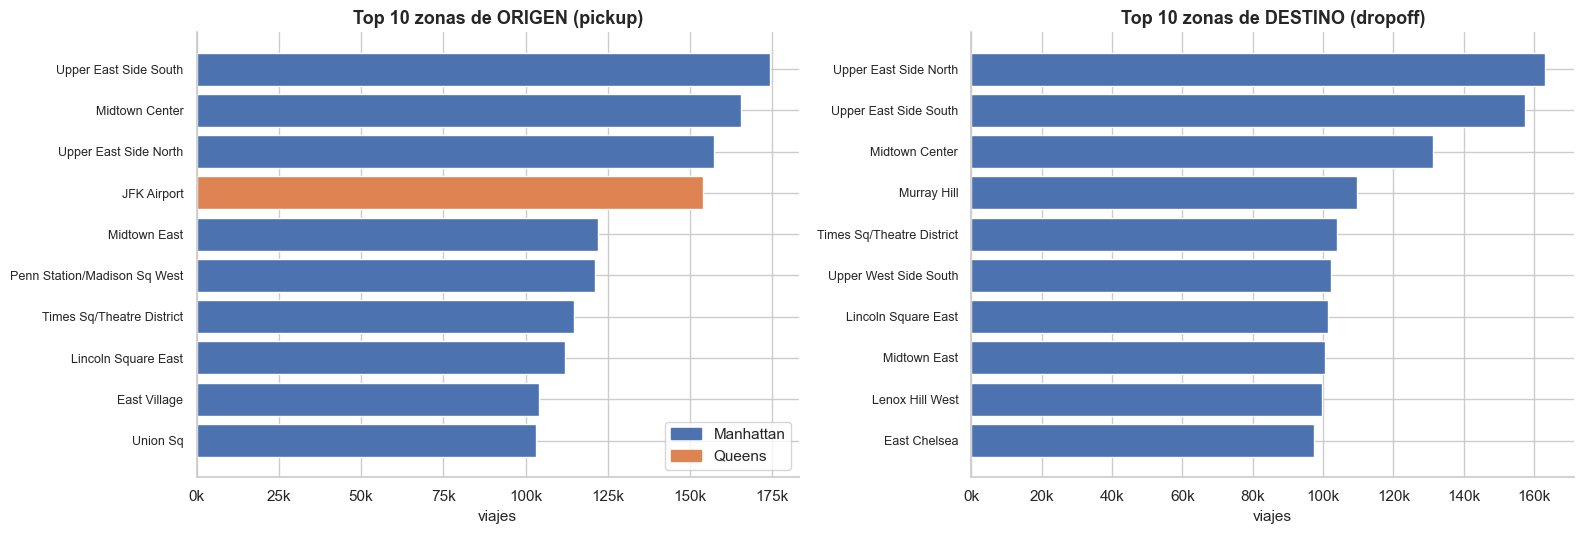

Pickups en Manhattan: 85.8%
Pickups en aeropuertos (JFK + LaGuardia): 6.3%
Cardinalidad de zonas: 261 orígenes / 260 destinos distintos


In [31]:
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches

zonas = pd.read_csv(Path('dataset') / 'taxi_zone_lookup.csv').set_index('LocationID')
colores_boro = {'Manhattan':'#4C72B0', 'Queens':'#DD8452', 'Brooklyn':'#55A868', 'Bronx':'#C44E52'}

fig, ax = plt.subplots(1, 2, figsize=(16, 5.5))
for j, (col, titulo) in enumerate([('PULocationID','Top 10 zonas de ORIGEN (pickup)'),
                                   ('DOLocationID','Top 10 zonas de DESTINO (dropoff)')]):
    top = df[col].value_counts().head(10)
    nombres = top.index.map(zonas['Zone'])
    boros   = top.index.map(zonas['Borough'])
    ax[j].barh(range(len(top)), top.values, color=[colores_boro.get(b,'gray') for b in boros])
    ax[j].set_yticks(range(len(top))); ax[j].set_yticklabels(nombres, fontsize=9)
    ax[j].invert_yaxis()
    ax[j].set_title(titulo); ax[j].set_xlabel('viajes')
    ax[j].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'{x/1e3:.0f}k'))
ax[0].legend(handles=[mpatches.Patch(color=c, label=b) for b,c in colores_boro.items()
                      if b in ('Manhattan','Queens')], loc='lower right')
plt.tight_layout(); plt.show()

pu_boro = df['PULocationID'].map(zonas['Borough'])
print(f"Pickups en Manhattan: {100*pu_boro.eq('Manhattan').mean():.1f}%")
print(f"Pickups en aeropuertos (JFK + LaGuardia): {100*df['PULocationID'].isin([132,138]).mean():.1f}%")
print(f"Cardinalidad de zonas: {df['PULocationID'].nunique()} orígenes / {df['DOLocationID'].nunique()} destinos distintos")

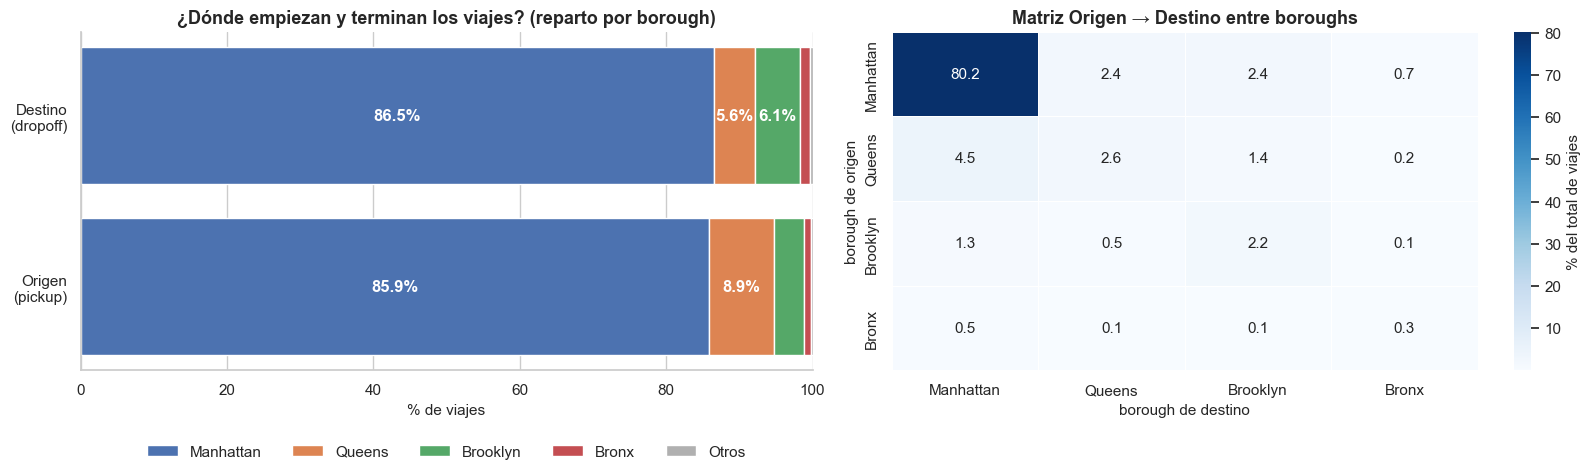

In [32]:
# La evidencia visual del Manhattan-centrismo: proporciones por borough y matriz O-D
pu_b = df['PULocationID'].map(zonas['Borough'])
do_b = df['DOLocationID'].map(zonas['Borough'])
orden = ['Manhattan','Queens','Brooklyn','Bronx','Otros']
colores = {'Manhattan':'#4C72B0','Queens':'#DD8452','Brooklyn':'#55A868','Bronx':'#C44E52','Otros':'#B0B0B0'}

def shares(s):
    v = s.value_counts(normalize=True)*100
    v = v.reindex(orden[:-1]).fillna(0)
    v['Otros'] = 100 - v.sum()
    return v

fig, ax = plt.subplots(1, 2, figsize=(16.5, 5))

# Panel izquierdo: barras 100% apiladas -> el reparto completo en una sola mirada
filas = {'Origen\n(pickup)': shares(pu_b), 'Destino\n(dropoff)': shares(do_b)}
for yi, (lbl, v) in enumerate(filas.items()):
    izq = 0
    for b in orden:
        ax[0].barh(lbl, v[b], left=izq, color=colores[b], label=b if yi == 0 else None)
        if v[b] > 5:
            ax[0].text(izq + v[b]/2, yi, f'{v[b]:.1f}%', ha='center', va='center',
                       color='white', fontweight='bold', fontsize=12)
        izq += v[b]
ax[0].set_xlim(0, 100); ax[0].set_xlabel('% de viajes')
ax[0].set_title('¿Dónde empiezan y terminan los viajes? (reparto por borough)')
ax[0].legend(ncol=5, loc='upper center', bbox_to_anchor=(0.5, -0.18), frameon=False)

# Panel derecho: matriz Origen -> Destino entre boroughs (% del total de viajes)
od = (pd.crosstab(pu_b, do_b, normalize=True)*100).reindex(index=orden[:-1], columns=orden[:-1])
sns.heatmap(od, annot=True, fmt='.1f', cmap='Blues', linewidths=.5,
            annot_kws={'fontsize': 11}, cbar_kws={'label': '% del total de viajes'}, ax=ax[1])
ax[1].set_title('Matriz Origen → Destino entre boroughs')
ax[1].set_xlabel('borough de destino'); ax[1].set_ylabel('borough de origen')
plt.tight_layout(); plt.show()

**Interpretación.** El negocio del yellow cab es **abrumadoramente Manhattan-céntrico**, y los tres gráficos lo evidencian en niveles distintos:

- Las **barras apiladas** muestran el reparto completo: **85,9% de los orígenes y 86,5% de los destinos** son Manhattan; Queens aporta el segundo bloque de orígenes (8,9%) casi enteramente por sus dos aeropuertos.
- La **matriz Origen → Destino** lo sella: el **80,2% de *todos* los viajes empieza y termina dentro de Manhattan**. El segundo flujo es Queens → Manhattan (4,5%) — la vuelta del aeropuerto a la ciudad — y los flujos que no tocan Manhattan son marginales (Brooklyn → Brooklyn, 2,2%).
- El **top-10 por zona** pone nombres: Upper East Side, Midtown y los nodos de transporte (Penn Station, Times Sq) encabezan, con **JFK como 4º origen (3,9%)** pero ausente de los destinos top — el yellow cab domina la *salida* del aeropuerto más que la llegada.

Para el modelo, esto confirma a la zona como feature valiosa pero plantea un desafío: con **~260 valores distintos** y fuerte concentración, las zonas tienen **alta cardinalidad** → no conviene one-hot puro; en la etapa de *feature engineering* (Azul) convendrá *frequency/target encoding* o agrupar por borough.

## 3. Planteo del problema de ML supervisado

**Problema (regresión):** predecir la **propensión a dejar propina** de un viaje, medida como la proporción de propina sobre la tarifa: **`tip_pct = tip_amount / fare_amount`**.

- **Tipo:** aprendizaje supervisado, **regresión** (target continuo) — Clase 1.
- **Universo de análisis:** **solo pagos con tarjeta** (`payment_type == 1`). En efectivo la propina no se registra (sesgo MNAR; ver 3.1), así que incluirlo entrenaría un *proxy del medio de pago* en vez de la conducta de propina.
- **Target — por qué un ratio y no el monto:** la gente propina pensando en un **porcentaje** del viaje, no en un monto absoluto; y el monto crudo `tip_amount` lo arrastran la distancia y la tarifa (mezcla "cuánto costó" con "cuánto propinó"). Construir el ratio `tip/fare` es **feature engineering visto en Clase 5** ("agregar *ratios* A/B guiados por conocimiento del dominio"). Dejamos `tip_amount` crudo como alternativa: misma pipeline, solo cambia `y`.
- **Features candidatas (sin fuga):** `trip_distance`, `duration_min`, `fare_amount`, `PULocationID`, `DOLocationID`, `passenger_count`, `hour`, `dow`, `RatecodeID`, `VendorID`. *(`fare_amount` es legítima: es conocida y **no contiene** la propina; sirve para ver si el % cambia con el tamaño del viaje.)*
- **Excluidas por fuga (leakage):** `total_amount` (contiene la propina como sumando → la regalaría) y `tip_amount` (es el numerador del target).
- **Selección fina de features:** *cuáles* de las candidatas realmente aportan **no se decide a priori** sino con **filtros e importancia (Clase 3: correlación, información mutua, PCA — tarea de Nico)**. Acá dejamos el **conjunto candidato razonado y sin fuga**, que es el insumo de esa etapa.

**Motivación.** Entender qué viajes generan más propina tiene valor directo: asignación de conductores, análisis de calidad de servicio por zona y franja horaria.

**Alternativa documentada (Plan B):** predecir `duration_min` (target limpio, disponible para *todos* los viajes). Desarrollada en `tp_grupal_eda_planB_duracion.ipynb` y conservada como respaldo y como *sanity check* comparativo (no se presenta).

### 3.1 Desafíos del dataset que debemos resolver para predecir la propina

El grupo propuso predecir la propina, así que la analizamos a fondo **antes** de decidir la limpieza (el tratamiento de outliers y de faltantes depende de cuál sea el *target*). La propina es un target **rico pero tramposo**: predecirla es viable, pero **solo si se resuelven cuatro desafíos**, y **cada uno se traduce en una decisión de preprocesamiento concreta**. Esto es, justamente, lo que la materia evalúa: *comprensión de los desafíos del dataset* y *justificación de las técnicas de preparación*.

**1. El target está censurado por la forma de pago (sesgo MNAR estructural).**
El taxímetro **solo registra la propina pagada con tarjeta**; las de efectivo figuran como `0`. Lo dice el *Trip Record User Guide* de la TLC: *"This field is automatically populated for credit card tips. Cash tips are not included."* En marzo 2026: **100%** de los pagos en efectivo tienen `tip = 0` y, en total, **~38% de los viajes** tienen `tip = 0` por **no registro**, no por ausencia de propina.
→ **Decisión:** restringir el universo a **pagos con tarjeta** (`payment_type == 1`). El modelo queda **válido solo para tarjeta**, y lo declaramos explícitamente como *alcance* (es una decisión informada, no una limitación oculta).

**2. Fuga de información (leakage) vía `total_amount`.**
Por construcción contable `total_amount = fare + impuestos + peajes + recargos + tip`: la propina **es un sumando del total**. Por eso `corr(total_amount, tip) ≈ 0.58` y, reconstruyendo `tip = total − (resto de componentes)`, se recupera el valor exacto en **~66%** de los viajes.
→ **Decisión:** **excluir `total_amount`** (y cualquier derivado) de las features. Es el punto más fino: el entrenamiento **no** elimina una variable con fuga — la toma como la *más* importante (corr casi perfecta) y da un desempeño **falso**. Se saca razonando, a priori.

**3. La propina con tarjeta es una opción *sugerida en pantalla*.**
La pantalla de pago ofrece porcentajes fijos (típicamente `{18, 20, 25, 30}%` del fare) más "otro": el target es **mayormente discreto** disfrazado de continuo.
→ **Decisión:** modelar el **ratio `tip_pct = tip/fare`** (Clase 5), que es la escala natural de esa elección. Como extensión podría **discretizarse** en franjas de propina (Clase 5) y plantearse como **clasificación**.

**4. El propio target tiene errores de calidad.**
Hay propinas **negativas**, viajes con **propina > tarifa**, y ratios disparados por tarifas de centavos.
→ **Decisión:** eliminar lo imposible (`tip ≥ 0`, `fare ≥ 2.50` = tarifa base mínima en NYC) y **winsorizar** los outliers plausibles del ratio con límites calculados en el *train* (sección 4.5).

> **Referencias (trampas conocidas de este dataset).**
> - TLC — *Yellow Taxi Trip Record User Guide / Data Dictionary*: la propina solo se registra para pagos con tarjeta ([nyc.gov/tlc](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page)).
> - SAS — *How much do New Yorkers tip taxi drivers?*: el sesgo por no registrar el efectivo ([blogs.sas.com](https://blogs.sas.com/content/iml/2016/05/02/new-yorkers-tip-taxis.html)).
> - NYC Data Science Academy — *Analysis on NYC Taxi Riders' Tipping Behavior*: los análisis se restringen a tarjeta por esta razón ([nycdatascience.com](https://nycdatascience.com/blog/student-works/data-analysis-on-nyc-taxi-riders-tipping-behavior/)).
> - El dato frecuentemente citado de que *"más del 40% no deja propina"* está sesgado justamente por el efectivo no registrado.

La celda siguiente reproduce la evidencia cuantitativa de los cuatro puntos.

In [33]:
# Evidencia que respalda por qué NO conviene predecir tip_amount.
# Releemos el crudo para que el análisis sea independiente del estado previo del notebook.
import pandas as pd
from pathlib import Path

_raw = pd.read_parquet(Path("dataset") / "yellow_tripdata_2026-03.parquet")
_n = len(_raw)
_pt = {1: "Credit card", 2: "Cash", 3: "No charge", 4: "Dispute", 5: "Unknown", 6: "Voided"}
_raw["_pago"] = _raw["payment_type"].map(_pt).fillna("Código " + _raw["payment_type"].astype(str))

# (1) Propina según forma de pago
_t = (_raw.groupby("_pago")
          .agg(viajes=("tip_amount", "size"),
               pct_con_propina=("tip_amount", lambda s: (s > 0).mean() * 100),
               tip_medio=("tip_amount", "mean"))
          .sort_values("viajes", ascending=False))
_t["pct_del_dataset"] = _t["viajes"] / _n * 100
print("(1) Propina según forma de pago:")
print(_t.round(2).to_string(), "\n")

# (2) Ceros estructurales
print(f"(2) tip == 0 en TODO el dataset: {(_raw['tip_amount'] == 0).mean() * 100:.1f}%")
print(f"    tip == 0 entre pagos en EFECTIVO: "
      f"{(_raw.loc[_raw['payment_type'] == 2, 'tip_amount'] == 0).mean() * 100:.1f}%\n")

# (3) Leakage vía total_amount
_comp = [c for c in ["fare_amount", "extra", "mta_tax", "tolls_amount", "improvement_surcharge",
                     "congestion_surcharge", "Airport_fee", "cbd_congestion_fee"] if c in _raw.columns]
_recon = _raw["total_amount"] - _raw[_comp].sum(axis=1)
print(f"(3) corr(total_amount, tip_amount) = {_raw['total_amount'].corr(_raw['tip_amount']):.3f}")
print(f"    tip reconstruido desde total_amount coincide (|err|<0.01) en "
      f"{((_recon - _raw['tip_amount']).abs() < 0.01).mean() * 100:.1f}% de los viajes\n")

# (4) Calidad del target
print("(4) Calidad del target tip_amount:")
print(f"    propinas negativas:        {(_raw['tip_amount'] < 0).sum():,}")
print(f"    propina mayor que la tarifa: {(_raw['tip_amount'] > _raw['fare_amount']).sum():,}")
print(f"    tip máximo:                ${_raw['tip_amount'].max():,.2f}")

del _raw  # liberar memoria


(1) Propina según forma de pago:
              viajes  pct_con_propina  tip_medio  pct_del_dataset
_pago                                                            
Credit card  2608830            90.21       4.16            66.01
Código 0      945748             9.34       0.45            23.93
Cash          353541             0.00       0.00             8.94
Dispute        31490             0.02       0.00             0.80
No charge      12842             0.03       0.00             0.32 

(2) tip == 0 en TODO el dataset: 38.2%
    tip == 0 entre pagos en EFECTIVO: 100.0%



(3) corr(total_amount, tip_amount) = 0.575
    tip reconstruido desde total_amount coincide (|err|<0.01) en 65.9% de los viajes

(4) Calidad del target tip_amount:
    propinas negativas:        40
    propina mayor que la tarifa: 25,222
    tip máximo:                $397.00


## 4. Preprocesamiento y limpieza del dataset

Seguimos el **flujo de preparación visto en clase**: primero restringimos el universo y limpiamos errores imposibles, luego **hacemos el split train/test**, y recién **después** ajustamos las transformaciones (imputación, outliers, escalado) **sobre el train** y las aplicamos al test, para evitar fuga de información.

### 4.1 Filtrado a pagos con tarjeta y limpieza de inconsistencias

Primero restringimos el dataset al **universo válido para el target** (tarjeta) y eliminamos lo **físicamente imposible o inservible** para el ratio. Los outliers *plausibles* no se borran acá: se winsorizan en 4.5.

In [34]:
# Universo de análisis: SOLO pagos con tarjeta (payment_type == 1).
# Motivo (ver 3.1): la propina en efectivo no se registra (MNAR); incluir efectivo
# entrenaría un proxy del medio de pago, no la conducta de propina.
df_card = df[df['payment_type'] == 1].copy()
n0 = len(df)
print(f'Viajes totales:      {n0:,}')
print(f'Viajes con tarjeta:  {len(df_card):,}  ({100*len(df_card)/n0:.1f}% del dataset)\n')

# Limpieza de registros imposibles / inservibles para el target tip_pct.
reglas = [
    ('duración en (0, 180] min',          (df_card['duration_min'] > 0) & (df_card['duration_min'] <= 180)),
    ('distancia en (0, 100] millas',      (df_card['trip_distance'] > 0) & (df_card['trip_distance'] <= 100)),
    ('fare >= 2.50 (tarifa base mínima)',  df_card['fare_amount'] >= 2.50),
    ('tip_amount >= 0',                    df_card['tip_amount'] >= 0),
    ('pickup en marzo 2026',               df_card['tpep_pickup_datetime'].between('2026-03-01','2026-03-31 23:59:59')),
]
n1 = len(df_card)
for nombre, cond in reglas:
    antes = len(df_card)
    df_card = df_card[cond.reindex(df_card.index).fillna(False)]
    print(f'{nombre:36s} -> elimina {antes-len(df_card):>8,} filas')
print('-'*64)
print(f'Filas finales: {len(df_card):,}  ({100*len(df_card)/n1:.1f}% del universo tarjeta)')

Viajes totales:      3,952,451
Viajes con tarjeta:  2,608,830  (66.0% del dataset)

duración en (0, 180] min             -> elimina   43,410 filas


distancia en (0, 100] millas         -> elimina   19,572 filas
fare >= 2.50 (tarifa base mínima)    -> elimina      136 filas
tip_amount >= 0                      -> elimina        0 filas


pickup en marzo 2026                 -> elimina       15 filas
----------------------------------------------------------------
Filas finales: 2,545,697  (97.6% del universo tarjeta)


#### Filtros físicos adicionales (coherencia cinemática y tarifaria)

Sumamos dos reglas de la literatura de limpieza del dataset TLC, que descartan registros **corruptos** sin tocar los outliers plausibles (esos se winsorizan en 4.5):

- **(a) Velocidad imposible:** descartamos viajes con velocidad media `distancia / duración > 100 mph`. En una ciudad crónicamente congestionada es físicamente imposible → delata un error de GPS o de reloj a bordo.
- **(b) Coherencia tarifa–distancia (solo tarifa estándar):** para `RatecodeID == 1` el taxímetro acumula ~US$2,50 por milla; si la tarifa cobrada es menor que `2,50 × distancia`, la distancia reportada está corrupta (error de GPS). **El filtro se desactiva para tarifas planas o negociadas** (JFK=2, Newark=3, negociada=5, etc.), donde el precio *no* depende de la distancia y forzar esta relación eliminaría datos válidos.

In [35]:
# Filtros físicos adicionales (literatura de limpieza del dataset TLC)
# (a) Velocidad imposible: ningún viaje urbano sostiene > 100 mph promedio.
n_prev = len(df_card)
vel_mph = df_card['trip_distance'] / (df_card['duration_min'] / 60)   # millas por hora
df_card = df_card[vel_mph <= 100]
print(f'(a) velocidad media > 100 mph                 -> elimina {n_prev-len(df_card):>8,} filas')

# (b) Coherencia tarifa-distancia SOLO para tarifa estándar (RatecodeID == 1).
#     Las tarifas PLANAS/negociadas (JFK=2, Newark=3, negociada=5...) NO siguen
#     esta relación, por eso quedan EXCLUIDAS del filtro.
n_prev = len(df_card)
es_estandar  = df_card['RatecodeID'] == 1
incoherente  = es_estandar & (df_card['fare_amount'] < 2.50 * df_card['trip_distance'])
df_card = df_card[~incoherente]
print(f'(b) tarifa estándar incoherente con distancia -> elimina {n_prev-len(df_card):>8,} filas')
print('-'*64)
print(f'Filas finales tras filtros físicos: {len(df_card):,}')

(a) velocidad media > 100 mph                 -> elimina      354 filas
(b) tarifa estándar incoherente con distancia -> elimina       68 filas
----------------------------------------------------------------
Filas finales tras filtros físicos: 2,545,275


### 4.2 Creación del target: `tip_pct` (ratio propina / tarifa)

Aplicamos **creación de features tipo A/B (Clase 5)**: el ratio `tip/fare` es la escala natural en la que las personas deciden la propina, y normaliza el efecto del tamaño del viaje.

In [36]:
# Target como RATIO (Clase 5: features matemáticas A/B guiadas por dominio).
df_card['tip_pct'] = df_card['tip_amount'] / df_card['fare_amount']

print('Distribución de tip_pct (propina / tarifa):')
print(df_card['tip_pct'].describe(percentiles=[.25, .5, .75, .9, .99]).round(3))
print(f"\nViajes con propina > 0: {(df_card['tip_pct'] > 0).mean()*100:.1f}%  "
      f"(coherente: en tarjeta la propina sí se registra)")

Distribución de tip_pct (propina / tarifa):


count    2545275.000
mean           0.248
std            0.159
min            0.000
25%            0.184
50%            0.265
75%            0.316
90%            0.377
99%            0.560
max           28.101
Name: tip_pct, dtype: float64

Viajes con propina > 0: 90.2%  (coherente: en tarjeta la propina sí se registra)


### 4.3 Split train / test (antes de transformar)

> **Por qué split primero.** Si imputáramos o escaláramos usando estadísticos de *todo* el dataset, el test 'vería' información del train (data leakage). Criterio de la materia (Clase 5): **calcular medianas, límites de outliers y parámetros de escalado SOLO con el train**, y aplicarlos al test.

In [37]:
from sklearn.model_selection import train_test_split

features = ['trip_distance','duration_min','fare_amount','PULocationID','DOLocationID',
            'passenger_count','hour','dow','RatecodeID','VendorID']
target = 'tip_pct'

X = df_card[features].copy()
y = df_card[target].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas')
print(f'Features: {features}')
print(f'Target:   {target}  (excluidos por leakage: total_amount, tip_amount)')

Train: 2,036,220 filas | Test: 509,055 filas
Features: ['trip_distance', 'duration_min', 'fare_amount', 'PULocationID', 'DOLocationID', 'passenger_count', 'hour', 'dow', 'RatecodeID', 'VendorID']
Target:   tip_pct  (excluidos por leakage: total_amount, tip_amount)


### 4.4 Tratamiento de valores faltantes (imputación robusta + indicador)

Los faltantes son **MAR/estructurales** (viajes Flex Fare). Imputamos con estadísticos **del train** y agregamos una bandera de faltante para no perder esa señal.

In [38]:
# Indicador de faltante (la ausencia es informativa -> viaje Flex Fare)
for split in (X_train, X_test):
    split['flex_fare_flag'] = split['passenger_count'].isna().astype(int)

# Imputación con estadísticos calculados SOLO en train
imput_passenger = X_train['passenger_count'].median()   # robusto
imput_ratecode  = X_train['RatecodeID'].mode()[0]        # categórica -> moda

for split in (X_train, X_test):
    split['passenger_count'] = split['passenger_count'].fillna(imput_passenger)
    split['RatecodeID']      = split['RatecodeID'].fillna(imput_ratecode)

print('Imputación passenger_count (mediana train):', imput_passenger)
print('Imputación RatecodeID (moda train):', imput_ratecode)
print('Nulos restantes en train:', int(X_train.isna().sum().sum()))
print('Nulos restantes en test: ', int(X_test.isna().sum().sum()))

Imputación passenger_count (mediana train): 1.0
Imputación RatecodeID (moda train): 1.0
Nulos restantes en train: 0
Nulos restantes en test:  0


### 4.5 Tratamiento de outliers (winsorización por IQR, ajustada en train)

Los errores imposibles ya se eliminaron en 4.1. A los **outliers plausibles** los **acotamos (winsorizamos)** a los límites IQR calculados en el train, en vez de borrarlos. Winsorizamos las features numéricas continuas **y el propio target** `tip_pct` (propinas extremas son ruido).

In [39]:
# Features numéricas continuas
cols_winsor = ['trip_distance', 'duration_min', 'fare_amount']
limites = {}
for c in cols_winsor:
    q1, q3 = X_train[c].quantile(.25), X_train[c].quantile(.75)
    iqr = q3 - q1
    limites[c] = (q1 - 1.5*iqr, q3 + 1.5*iqr)
for c, (lo, hi) in limites.items():
    for split in (X_train, X_test):
        split[c] = split[c].clip(lower=max(lo, 0), upper=hi)
    print(f'{c}: acotado a [{max(lo,0):.2f}, {hi:.2f}] (límites del train)')

# Target: límites calculados SOLO en y_train, aplicados a ambos
q1, q3 = y_train.quantile(.25), y_train.quantile(.75)
iqr = q3 - q1
y_lo, y_hi = max(q1 - 1.5*iqr, 0), q3 + 1.5*iqr
y_train = y_train.clip(y_lo, y_hi)
y_test  = y_test.clip(y_lo, y_hi)
print(f'tip_pct (target): acotado a [{y_lo:.3f}, {y_hi:.3f}] (límites del train)')

trip_distance: acotado a [0.00, 7.00] (límites del train)
duration_min: acotado a [0.00, 41.58] (límites del train)
fare_amount: acotado a [0.00, 40.80] (límites del train)


tip_pct (target): acotado a [0.000, 0.515] (límites del train)


### 4.6 Escalado / normalización

Usamos **`RobustScaler`** (centra en la mediana y escala por el IQR), coherente con el enfoque robusto: es **menos sensible a los outliers** restantes. Escalamos solo las features **numéricas**; las categóricas (zonas, vendor, ratecode) se codifican en la etapa de *feature engineering* (Azul).

In [40]:
from sklearn.preprocessing import RobustScaler

num_features = ['trip_distance', 'duration_min', 'fare_amount', 'passenger_count']
scaler = RobustScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[num_features] = scaler.fit_transform(X_train[num_features])  # fit SOLO en train
X_test_scaled[num_features]  = scaler.transform(X_test[num_features])       # transform en test

print('Centro (mediana) usado por el scaler:', dict(zip(num_features, scaler.center_.round(2))))
print('Escala (IQR) usada por el scaler:    ', dict(zip(num_features, scaler.scale_.round(2))))
X_train_scaled[num_features].describe().round(2)

Centro (mediana) usado por el scaler: {'trip_distance': 1.73, 'duration_min': 12.78, 'fare_amount': 13.5, 'passenger_count': 1.0}
Escala (IQR) usada por el scaler:     {'trip_distance': 2.39, 'duration_min': 13.53, 'fare_amount': 12.6, 'passenger_count': 1.0}


,trip_distance,duration_min,fare_amount,passenger_count
count,2036220.00,2036220.00,2036220.00,2036220.00
mean,0.37,0.24,0.31,0.22
std,0.91,0.82,0.87,0.62
min,-0.72,-0.94,-0.83,-1.00
25%,-0.30,-0.37,-0.33,0.00
50%,0.00,0.00,0.00,0.00
75%,0.70,0.63,0.67,0.00
max,2.20,2.13,2.17,5.00


### 4.7 Resultado del preprocesamiento

In [41]:
print('Dataset listo para entrenar (no se entrena, según consigna):')
print(f'  X_train: {X_train_scaled.shape}   y_train: {y_train.shape}')
print(f'  X_test:  {X_test_scaled.shape}    y_test:  {y_test.shape}')
print(f'  Target:  tip_pct (propina/tarifa) | universo: pagos con tarjeta')
print(f'  Features finales: {list(X_train_scaled.columns)}')
X_train_scaled.head()

Dataset listo para entrenar (no se entrena, según consigna):
  X_train: (2036220, 11)   y_train: (2036220,)
  X_test:  (509055, 11)    y_test:  (509055,)
  Target:  tip_pct (propina/tarifa) | universo: pagos con tarjeta
  Features finales: ['trip_distance', 'duration_min', 'fare_amount', 'PULocationID', 'DOLocationID', 'passenger_count', 'hour', 'dow', 'RatecodeID', 'VendorID', 'flex_fare_flag']


,trip_distance,duration_min,fare_amount,PULocationID,DOLocationID,passenger_count,hour,dow,RatecodeID,VendorID,flex_fare_flag
103344,0.079498,0.004926,0.000000,66,49,0.0,11,0,1.0,2,0
1924904,0.447699,0.051724,0.222222,142,75,1.0,14,4,1.0,1,0
2809771,0.334728,0.637931,0.500000,186,142,0.0,18,6,1.0,2,0
363419,0.782427,0.754926,0.500000,144,161,0.0,22,2,1.0,1,0
1605994,-0.518828,-0.463054,-0.500000,186,90,0.0,15,1,1.0,2,0


---
### Cierre de la Parte 1 y enganche con el resto del grupo

Dejamos el dataset **filtrado a pagos con tarjeta, limpio, imputado, con outliers acotados, escalado de forma robusta y separado en train/test**, con el problema definido: **regresión de `tip_pct`**.

- **Azul — Feature engineering** parte de `X_train_scaled` / `X_test_scaled`: *cyclic encoding* de `hour`/`dow`, codificación de zonas `PULocationID`/`DOLocationID` (alta cardinalidad → *frequency / target encoding*, Clase 4), y posible **discretización** del target en franjas de propina (Clase 5).
- **Nicolás — Reducción de dimensionalidad / selección de features**: filtros (correlación, información mutua) y **PCA** (Clase 3) para quedarse con las variables que realmente aportan.
- **Plan B (`duration_min`)** queda como notebook alternativo (`tp_grupal_eda_planB_duracion.ipynb`) y como *sanity check* comparativo entre ambos targets (no se presenta).